<a href="https://colab.research.google.com/github/divyakanojia/Deeplearning/blob/deeplearningmaterial/rnn_sine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
x = np.linspace(0, 50, 501)

In [ ]:
y = np.sin(x)

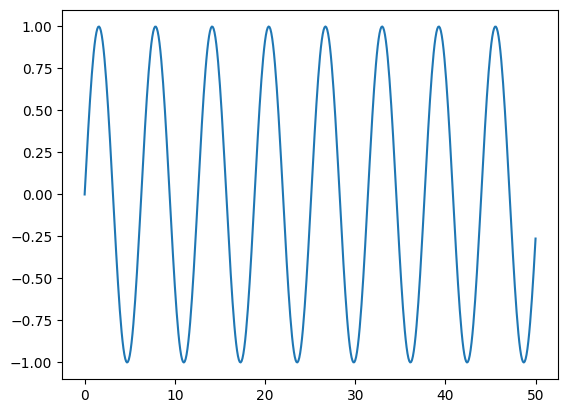

In [ ]:
plt.plot(x, y)

In [ ]:
df = pd.DataFrame(y, index = x, columns=['Sine'])
df.head()

,Sine
0.0,0.000000
0.1,0.099833
0.2,0.198669
0.3,0.295520
0.4,0.389418


In [ ]:
len(df)

501

In [ ]:
test_percent = 0.2

In [ ]:
501 * (20/100)

100.2

In [ ]:
train_df = df.iloc[:400]
test_df = df.iloc[400:]

In [ ]:
train_df.head()

,Sine
0.0,0.000000
0.1,0.099833
0.2,0.198669
0.3,0.295520
0.4,0.389418


In [ ]:
test_df.head()

,Sine
40.0,0.745113
40.1,0.674808
40.2,0.597760
40.3,0.514740
40.4,0.426577


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
scaler.fit(train_df)

MinMaxScaler()

In [ ]:
train = scaler.transform(train_df)
test = scaler.transform(test_df)

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
generator = TimeseriesGenerator(train, train, length = 2, batch_size = 1)

In [ ]:
generator[0]

(array([[[0.49999912],
         [0.54991622]]]),
 array([[0.59933458]]))

In [ ]:
generator[1]

(array([[[0.54991622],
         [0.59933458]]]),
 array([[0.64776041]]))

In [ ]:
generator = TimeseriesGenerator(train, train, length = 50, batch_size = 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [ ]:
length = 50
n_features = 1

In [ ]:
model = Sequential()

model.add(SimpleRNN(50, input_shape=(50, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(generator, epochs = 5)

Epoch 1/5
 22/350 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4417

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0586
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.1782e-04
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.7839e-05
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0015
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 4.3242e-05


In [ ]:
loss_df = pd.DataFrame(model.history.history)

In [ ]:
loss_df.head()

,loss
0,0.012015
1,0.000093
2,0.000210
3,0.001172
4,0.000069


<Axes: >

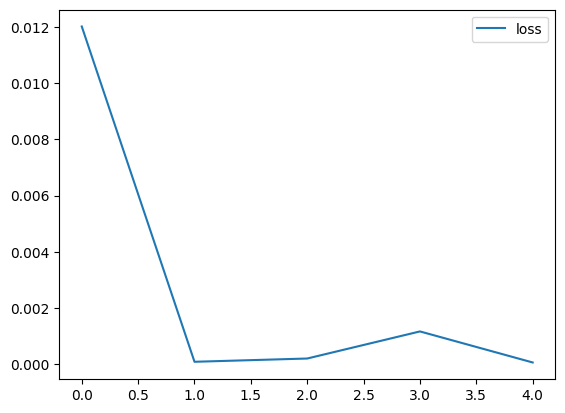

In [ ]:
loss_df.plot()

In [ ]:
first_batch = train[-50:]

In [ ]:
first_batch.shape

(50, 1)

In [ ]:
first_batch = first_batch.reshape(1, length, n_features)

In [ ]:
first_batch.shape

(1, 50, 1)

In [ ]:
model.predict(first_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


array([[0.8483541]], dtype=float32)

In [ ]:
len(test)

101

In [ ]:
test_predictions = []
first_batch = train[-length:]
current_batch = first_batch.reshape(1, length, n_features)

for i in range(len(test)):
    current_prediction = model.predict(current_batch)[0]
    test_predictions.append(current_prediction)
    current_batch = np.append(current_batch[:, 1:, :], [[current_prediction]], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

In [ ]:
len(test_predictions)

101

In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)

In [ ]:
test_df.head()

,Sine
40.0,0.745113
40.1,0.674808
40.2,0.597760
40.3,0.514740
40.4,0.426577


In [ ]:
test_df["RNN Predictions"] = true_predictions

<ipython-input-39-cedd1787eb99>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["RNN Predictions"] = true_predictions


In [ ]:
test_df.head()

,Sine,RNN Predictions
40.0,0.745113,0.696704
40.1,0.674808,0.629891
40.2,0.597760,0.550868
40.3,0.514740,0.465042
40.4,0.426577,0.370363


<Axes: >

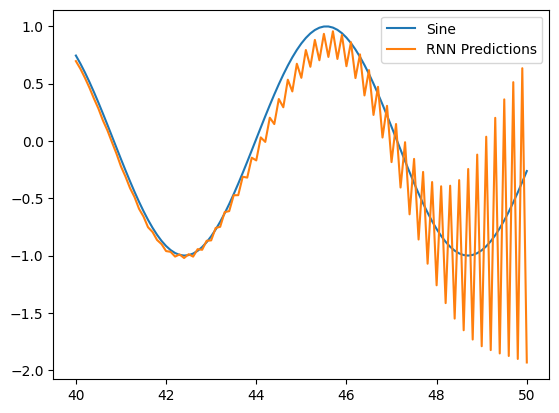

In [ ]:
test_df.plot()

In [ ]:
from tensorflow.keras.layers import LSTM

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(patience=2)

In [ ]:
length = 40

generator = TimeseriesGenerator(train, train, length=length, batch_size=1)

test_generator = TimeseriesGenerator(test, test, length=length, batch_size=1)

In [ ]:
model = Sequential()

model.add(LSTM(50, input_shape=(length, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(generator, epochs=30, validation_data=test_generator, callbacks=[early_stop])

Epoch 1/30
 16/360 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7552

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1185 - val_loss: 3.0901e-04
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2.5839e-04 - val_loss: 2.9093e-04
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 2.0450e-04 - val_loss: 1.1762e-04
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.5128e-04 - val_loss: 8.1368e-05
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1.4745e-04 - val_loss: 4.6126e-05
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.7893e-05 - val_loss: 1.8472e-04
Epoch 7/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.5701e-04 - val_loss: 2.1334e-05
Epoch 8/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 3.7739e-05 - val_loss: 4.2795e-06
Epoch 9/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2.1499e-05 - val_loss: 6.5376e-06
Epoch 10/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 2.1886e-05 - val_loss: 4.1488e-06
Epoch 11/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.

In [ ]:
test_predictions = []
first_batch = train[-length:]
current_batch = first_batch.reshape(1, length, 1)

for i in range(len(test)):
    current_prediction = model.predict(current_batch)[0]
    test_predictions.append(current_prediction)
    current_batch = np.append(current_batch[:, 1:, :], [[current_prediction]], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)

In [ ]:
test_df["LSTM Predictions"] = true_predictions

<ipython-input-50-50deca349239>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["LSTM Predictions"] = true_predictions


In [ ]:
test_df.head()

,Sine,RNN Predictions,LSTM Predictions
40.0,0.745113,0.696704,0.690125
40.1,0.674808,0.629891,0.617309
40.2,0.597760,0.550868,0.535266
40.3,0.514740,0.465042,0.445577
40.4,0.426577,0.370363,0.349774


<Axes: >

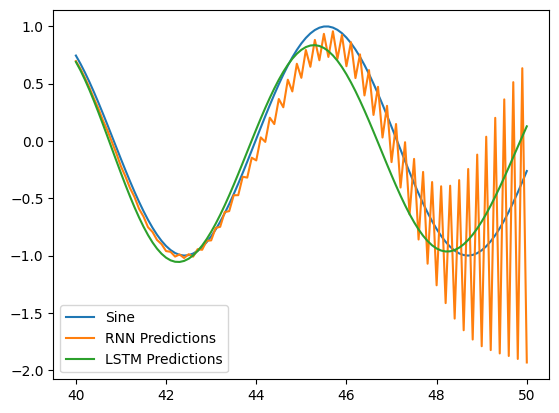

In [ ]:
test_df.plot()